In [1]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer

## Part 1: Features Setup/Further Refining of Data

In [2]:
final_df = pd.read_csv('./data/finalCards.csv')
# color 'U' is Blue, 'B' is Black

final_df.columns

Index(['uuid', 'cardName', 'availability', 'colorIdentity', 'defense',
       'edhrecRank', 'edhrecSaltiness', 'finishes', 'isAlternative',
       'isGameChanger', 'isPromo', 'isReprint', 'isReserved', 'keywords',
       'layout', 'loyalty', 'manaCost', 'manaValue', 'cardNumber', 'power',
       'rarity', 'setCode', 'subtypes', 'supertypes', 'text', 'toughness',
       'types', 'variations', 'price', 'commander', 'setName', 'releaseDate',
       'scryfallId', 'tcgplayerProductId', 'multiverseId', 'isHuman',
       'isElemental', 'isDragon', 'isSpirit', 'isAngel', 'isElf', 'isVampire',
       'isZombie', 'isBeast', 'isWizard', 'isSoldier', 'isKnight', 'isCleric',
       'isWarrior', 'isRogue', 'isShaman', 'isDruid', 'isCreature',
       'isPlaneswalker', 'isMTGO', 'isLegal', 'isBanned', 'isBattle',
       'isFlying'],
      dtype='str')

In [3]:
#final_df['Zscore'] = zscore(final_df['price'])

#outliers = final_df[final_df['Zscore'].abs() > 3]
#outliers['price']

In [4]:
final_df.commander = final_df.commander.map({'NotLegal':0, 'Banned':0.5, 'Legal':1})
final_df.colorIdentity = final_df.colorIdentity.str.replace(',', '')
final_df.rarity = final_df.rarity.map({'common':0, 'special':0.5, 'uncommon':1, 'rare':2, 'mythic':3})

#final_df = final_df[final_df['Zscore'].abs() <= 3]
#final_df = final_df.drop(columns=['Zscore'])
#print(len(final_df))
#final_df.sort_values(by='price', ascending=False)['price']

In [5]:
noncreature_df = final_df.copy()
noncreature_df = noncreature_df[(noncreature_df['isCreature'] != 1) & (noncreature_df['isReprint'] == 0)]
noncreature_df = noncreature_df[[
       'uuid', 'cardName', 'availability', 'colorIdentity',
       'edhrecRank', 'edhrecSaltiness', 'finishes', 'isAlternative',
       'isGameChanger', 'isPromo', 'isReserved', 'keywords',
       'layout', 'loyalty', 'manaValue', 'cardNumber',
       'rarity', 'setCode', 'subtypes', 'supertypes', 'text',
       'types', 'price', 'commander', 'setName', 'releaseDate',
       'isPlaneswalker', 'isBattle', 'isFlying'
       ]]

print(len(noncreature_df))
noncreature_df.isna().sum()

18251


uuid                   0
cardName               0
availability           0
colorIdentity          0
edhrecRank           957
edhrecSaltiness     3249
finishes               0
isAlternative          0
isGameChanger          0
isPromo                0
isReserved             0
keywords               0
layout                 0
loyalty            17743
manaValue              0
cardNumber             0
rarity                 0
setCode                0
subtypes               0
supertypes             0
text                   5
types                  0
price                  0
commander              0
setName                0
releaseDate            0
isPlaneswalker         0
isBattle               0
isFlying               0
dtype: int64

In [6]:
planeswalker_df = final_df[(final_df['isPlaneswalker'] == True)  & (final_df['isReprint'] == 0)]
planeswalker_df = planeswalker_df.drop(columns=['isReprint', 'variations', 'defense', 
                                                'power', 'toughness', 'isPlaneswalker',
                                                'isLegal', 'isBanned', 'isMTGO', 
                                                'manaCost'])
planeswalker_df.head()

,uuid,cardName,availability,colorIdentity,edhrecRank,edhrecSaltiness,finishes,isAlternative,isGameChanger,isPromo,...,isSoldier,isKnight,isCleric,isWarrior,isRogue,isShaman,isDruid,isCreature,isBattle,isFlying
85,00396ed6-b91d-5c78-8760-bb22d8f3e9ca,"Tevesh Szat, Doom of Fools","mtgo, paper",B,3174.0,0.57,"nonfoil, foil",False,False,False,...,False,False,False,False,False,False,False,False,False,False
87,003d9ecd-53bc-55c7-993f-26ec405f71e4,"Gideon, Martial Paragon","mtgo, paper",W,15747.0,0.37,foil,False,False,False,...,False,False,False,False,False,False,False,False,False,False
312,00d36b0f-e866-54df-b4aa-447ba0f681e2,"Huatli, the Sun's Heart","arena, mtgo, paper",G W,7026.0,0.53,"nonfoil, foil",False,False,False,...,False,False,False,False,False,False,False,False,False,False
643,01b81265-d14d-53ed-9d1c-a3db1896b055,Mordenkainen,"arena, mtgo, paper",U,7198.0,0.30,"nonfoil, foil",False,False,False,...,False,False,False,False,False,False,False,False,False,False
771,0212b149-6b3d-59e5-8709-9f2cba006dae,"Nicol Bolas, the Deceiver","mtgo, paper",B R U,12059.0,0.59,foil,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
print(len(planeswalker_df))
planeswalker_df.isna().sum()

513


uuid                   0
cardName               0
availability           0
colorIdentity          0
edhrecRank            10
edhrecSaltiness       21
finishes               0
isAlternative          0
isGameChanger          0
isPromo                0
isReserved             0
keywords               0
layout                 0
loyalty                5
manaValue              0
cardNumber             0
rarity                 0
setCode                0
subtypes               0
supertypes             0
text                   0
types                  0
price                  0
commander              0
setName                0
releaseDate            0
scryfallId             0
tcgplayerProductId    10
multiverseId          78
isHuman                0
isElemental            0
isDragon               0
isSpirit               0
isAngel                0
isElf                  0
isVampire              0
isZombie               0
isBeast                0
isWizard               0
isSoldier              0


In [8]:
creature_df = final_df.copy()
creature_df = creature_df[(creature_df['isCreature'] == 1) & (creature_df['isReprint'] == 0)]
creature_df = creature_df[['availability', 'cardName', 'colorIdentity',
       'edhrecRank', 'edhrecSaltiness', 'finishes', 'isAlternative',
       'isGameChanger', 'isPromo', 'isReserved', 'keywords',
       'manaValue', 'power', 'rarity', 'subtypes', 
       'supertypes', 'toughness', 'types', 'price', 'commander', 'isHuman',
       'isElemental', 'isDragon', 'isSpirit', 'isAngel', 'isElf', 'isVampire',
       'isZombie', 'isBeast', 'isWizard', 'isSoldier', 'isKnight', 'isCleric',
       'isWarrior', 'isRogue', 'isShaman', 'isDruid', 'isCreature',
       'isPlaneswalker', 'isFlying', 'isBattle']]

# text, cardName, scryfall ids

print(len(creature_df))
creature_df.isna().sum()

22685


availability          0
cardName              0
colorIdentity         0
edhrecRank          437
edhrecSaltiness    3923
finishes              0
isAlternative         0
isGameChanger         0
isPromo               0
isReserved            0
keywords              0
manaValue             0
power               301
rarity                0
subtypes              0
supertypes            0
toughness           224
types                 0
price                 0
commander             0
isHuman               0
isElemental           0
isDragon              0
isSpirit              0
isAngel               0
isElf                 0
isVampire             0
isZombie              0
isBeast               0
isWizard              0
isSoldier             0
isKnight              0
isCleric              0
isWarrior             0
isRogue               0
isShaman              0
isDruid               0
isCreature            0
isPlaneswalker        0
isFlying              0
isBattle              0
dtype: int64

In [9]:
def priceOutlier(df):
    df['Zscore'] = zscore(df['price'])

    no_outliers = df[df['Zscore'].abs() <= 3]
    print(len(df), len(no_outliers))

    return no_outliers

In [10]:
noncreature_df = priceOutlier(noncreature_df)
noncreature_df['price'].sort_values(ascending=False)

18251 18199


82824    1292.893333
53072    1192.840000
43401    1184.793333
76079    1146.665000
2701     1121.352000
            ...     
50380       0.104000
36020       0.100000
73087       0.030000
50670       0.030000
13008       0.020000
Name: price, Length: 18199, dtype: float64

In [11]:
planeswalker_df = priceOutlier(planeswalker_df)
planeswalker_df['price'].sort_values(ascending=False)

513 509


19403    92.325000
21072    81.158333
35258    68.196667
69831    59.036000
51666    55.130000
           ...    
91303     0.256000
56728     0.253333
89584     0.247778
44804     0.232222
78387     0.230000
Name: price, Length: 509, dtype: float64

In [12]:
creature_df = priceOutlier(creature_df)
creature_df['price'].sort_values(ascending=False)

22685 22578


17306    238.160000
53209    236.796000
15834    234.730000
75613    229.632500
16662    224.366667
            ...    
831        0.090000
91830      0.082000
45825      0.030000
29011      0.030000
89391      0.020000
Name: price, Length: 22578, dtype: float64

In [13]:
# how do we handle cases like these that are clearly unique
# and have "special" subtypes?
#creature_df.subtypes = creature_df.subtypes.str.replace('Lady of Proper Etiquette', 'Lady-of-Proper-Etiquette')
#creature_df.subtypes = creature_df.subtypes.str.replace('The Biggest Baddest Nastiest', 'The-Biggest-Baddest-Nastiest')

#creature_df.subtypes = creature_df.subtypes.str.replace('and/or', ',')
#creature_df.subtypes = creature_df.subtypes.str.replace(',', '')

In [14]:
"""
creature_df.keywords = creature_df.keywords.str.replace('Partner with', 'Partner-with')
creature_df.keywords = creature_df.keywords.str.replace('Hexproof from', 'Hexproof-from')
creature_df.keywords = creature_df.keywords.str.replace('Max speed', 'Max-speed')
creature_df.keywords = creature_df.keywords.str.replace('Pack tactics', 'Pack-tactics')
creature_df.keywords = creature_df.keywords.str.replace('Start your engines!', 'Start-your-engines!')
creature_df.keywords = creature_df.keywords.str.replace('More Than Meets the Eye', 'More-Than-Meets-the-Eye')
creature_df.keywords = creature_df.keywords.str.replace('Will of the Council', 'Will-of-the-Council')
creature_df.keywords = creature_df.keywords.str.replace('Open an Attraction', 'Open-an-Attraction')
creature_df.keywords = creature_df.keywords.str.replace('Roll to Visit Your Attractions', 'Roll-to-Visit-Your-Attractions')
creature_df.keywords = creature_df.keywords.str.replace('Venture into the dungeon', 'Venture-into-the-dungeon')
creature_df.keywords = creature_df.keywords.str.replace('Choose a background', 'Choose-a-background')
"""

"\ncreature_df.keywords = creature_df.keywords.str.replace('Partner with', 'Partner-with')\ncreature_df.keywords = creature_df.keywords.str.replace('Hexproof from', 'Hexproof-from')\ncreature_df.keywords = creature_df.keywords.str.replace('Max speed', 'Max-speed')\ncreature_df.keywords = creature_df.keywords.str.replace('Pack tactics', 'Pack-tactics')\ncreature_df.keywords = creature_df.keywords.str.replace('Start your engines!', 'Start-your-engines!')\ncreature_df.keywords = creature_df.keywords.str.replace('More Than Meets the Eye', 'More-Than-Meets-the-Eye')\ncreature_df.keywords = creature_df.keywords.str.replace('Will of the Council', 'Will-of-the-Council')\ncreature_df.keywords = creature_df.keywords.str.replace('Open an Attraction', 'Open-an-Attraction')\ncreature_df.keywords = creature_df.keywords.str.replace('Roll to Visit Your Attractions', 'Roll-to-Visit-Your-Attractions')\ncreature_df.keywords = creature_df.keywords.str.replace('Venture into the dungeon', 'Venture-into-the-

In [15]:
# https://mtg.wiki/page/Flavor_word
# there's way too many of these

"""
creature_df.keywords = creature_df.keywords.str.replace('Allure of Slaanesh', 'Allure-of-Slaanesh')
creature_df.keywords = creature_df.keywords.str.replace('Locus of Slaanesh', 'Locus-of-Slaanesh')
creature_df.keywords = creature_df.keywords.str.replace('Go to Sleep', 'Go-to-Sleep')
creature_df.keywords = creature_df.keywords.str.replace('How Civil of You', 'How-Civil-of-You')
creature_df.keywords = creature_df.keywords.str.replace('10000 Needles', '10000-Needles')
creature_df.keywords = creature_df.keywords.str.replace('I. AM. TALKING!', 'I.AM.TALKING!')
creature_df.keywords = creature_df.keywords.str.replace('Glory of Battle', 'Glory-of-Battle')
creature_df.keywords = creature_df.keywords.str.replace('Echo of the Lost', 'Echo-of-the-Lost')
creature_df.keywords = creature_df.keywords.str.replace('Look to the Stars', 'Look-to-the-Stars')
creature_df.keywords = creature_df.keywords.str.replace('Scavenge the Dead', 'Scavenge-the-Dead')
creature_df.keywords = creature_df.keywords.str.replace('Aegis of the Emperor', 'Aegis-of-the-Emperor')
creature_df.keywords = creature_df.keywords.str.replace('Rules of Combat', 'Rules-of-Combat')
creature_df.keywords = creature_df.keywords.str.replace('Bring it Down!', 'Bring-it-Down!')
creature_df.keywords = creature_df.keywords.str.replace('Meet in Reverse', 'Meet-in-Reverse')
creature_df.keywords = creature_df.keywords.str.replace('Terror from the Deep', 'Terror-from-the-Deep')
creature_df.keywords = creature_df.keywords.str.replace('Leading from the Front', 'Leading-from-the-Front')
creature_df.keywords = creature_df.keywords.str.replace('Hunt for Heresy', 'Hunt-for-Heresy')
creature_df.keywords = creature_df.keywords.str.replace('Hunters for Hire', 'Hunters-for-Hire')
creature_df.keywords = creature_df.keywords.str.replace('One for My Baby', 'One for My Baby')
creature_df.keywords = creature_df.keywords.str.replace('The Most Important Punch in History', 'The-Most-Important-Punch-in-History')
"""

"\ncreature_df.keywords = creature_df.keywords.str.replace('Allure of Slaanesh', 'Allure-of-Slaanesh')\ncreature_df.keywords = creature_df.keywords.str.replace('Locus of Slaanesh', 'Locus-of-Slaanesh')\ncreature_df.keywords = creature_df.keywords.str.replace('Go to Sleep', 'Go-to-Sleep')\ncreature_df.keywords = creature_df.keywords.str.replace('How Civil of You', 'How-Civil-of-You')\ncreature_df.keywords = creature_df.keywords.str.replace('10000 Needles', '10000-Needles')\ncreature_df.keywords = creature_df.keywords.str.replace('I. AM. TALKING!', 'I.AM.TALKING!')\ncreature_df.keywords = creature_df.keywords.str.replace('Glory of Battle', 'Glory-of-Battle')\ncreature_df.keywords = creature_df.keywords.str.replace('Echo of the Lost', 'Echo-of-the-Lost')\ncreature_df.keywords = creature_df.keywords.str.replace('Look to the Stars', 'Look-to-the-Stars')\ncreature_df.keywords = creature_df.keywords.str.replace('Scavenge the Dead', 'Scavenge-the-Dead')\ncreature_df.keywords = creature_df.keyw

In [16]:
#creature_df.keywords = creature_df.keywords.str.replace(',', '')

## Part 2: Encoding

In [17]:
one_hot_encoding_creature_df = creature_df.copy()
one_hot_encoding_planeswalker_df = planeswalker_df.copy()
one_hot_encoding_noncreature_df = noncreature_df.copy()
#one_hot_encoding_df['subtypes'] = creature_df['subtypes'].str.split()
#one_hot_encoding_df.subtypes

In [18]:
def encodeFeatures(df):
    df['colorIdentity'] = df['colorIdentity'].str.split()
    df['availability'] = df['availability'].str.replace(',', '')
    df['availability'] = df['availability'].str.split()
    df['finishes'] = df['finishes'].str.replace(',', '')
    df['finishes'] = df['finishes'].str.split()

    mlb = MultiLabelBinarizer()

    encoded_colors = mlb.fit_transform(df['colorIdentity'])
    colors_df = pd.DataFrame(encoded_colors, columns='c_'+mlb.classes_, index=df.index)
    colors_df = colors_df.drop(colors_df.columns[-1], axis=1)

    encoded_availability = mlb.fit_transform(df['availability'])
    availability_df = pd.DataFrame(encoded_availability, columns='a_'+mlb.classes_, index=df.index)
    availability_df = availability_df.drop(availability_df.columns[-1], axis=1)

    encoded_finishes = mlb.fit_transform(df['finishes'])
    finishes_df = pd.DataFrame(encoded_finishes, columns='f_'+mlb.classes_, index=df.index)
    finishes_df = finishes_df.drop(finishes_df.columns[-1], axis=1)

    features = pd.concat([colors_df, availability_df, finishes_df], axis=1) # keywords_df, subtypes_df
    print(features.columns)

    return features

In [19]:
creature_features = encodeFeatures(one_hot_encoding_creature_df)
noncreature_features = encodeFeatures(one_hot_encoding_noncreature_df)
planeswalker_features = encodeFeatures(one_hot_encoding_planeswalker_df)

Index(['c_B', 'c_Colorless', 'c_G', 'c_R', 'c_U', 'a_arena', 'a_mtgo',
       'f_etched', 'f_foil'],
      dtype='str')
Index(['c_B', 'c_Colorless', 'c_G', 'c_R', 'c_U', 'a_arena', 'a_mtgo',
       'f_etched', 'f_foil'],
      dtype='str')
Index(['c_B', 'c_Colorless', 'c_G', 'c_R', 'c_U', 'a_arena', 'a_mtgo',
       'f_etched', 'f_foil'],
      dtype='str')


In [20]:
creature_features

,c_B,c_Colorless,c_G,c_R,c_U,a_arena,a_mtgo,f_etched,f_foil
3,0,0,1,1,0,0,1,0,1
10,1,0,0,0,0,0,0,0,1
13,1,0,0,1,1,1,1,0,1
28,0,0,0,1,0,0,1,0,1
29,1,0,1,0,1,1,1,0,1
...,...,...,...,...,...,...,...,...,...
94101,0,0,0,1,1,0,1,0,1
94103,1,0,1,0,1,0,1,0,1
94111,0,0,1,0,0,1,1,0,1
94113,0,0,0,0,0,0,1,0,0


## Part 3: Consolidating Data

In [21]:
creatures_df = creature_df.copy()
creatures_df = creatures_df.join(creature_features)
creatures_df = creatures_df.drop(columns=['availability', 'finishes'])

print(len(creatures_df))
creatures_df.isna().sum()

22578


cardName              0
colorIdentity         0
edhrecRank          433
edhrecSaltiness    3904
isAlternative         0
isGameChanger         0
isPromo               0
isReserved            0
keywords              0
manaValue             0
power               298
rarity                0
subtypes              0
supertypes            0
toughness           221
types                 0
price                 0
commander             0
isHuman               0
isElemental           0
isDragon              0
isSpirit              0
isAngel               0
isElf                 0
isVampire             0
isZombie              0
isBeast               0
isWizard              0
isSoldier             0
isKnight              0
isCleric              0
isWarrior             0
isRogue               0
isShaman              0
isDruid               0
isCreature            0
isPlaneswalker        0
isFlying              0
isBattle              0
Zscore                0
c_B                   0
c_Colorless     

In [22]:
noncreatures_df = noncreature_df.copy()
noncreatures_df = noncreatures_df.join(noncreature_features)
noncreatures_df = noncreatures_df.drop(columns=['availability', 'finishes'])

print(len(noncreatures_df))
noncreatures_df.isna().sum()

18199


uuid                   0
cardName               0
colorIdentity          0
edhrecRank           944
edhrecSaltiness     3236
isAlternative          0
isGameChanger          0
isPromo                0
isReserved             0
keywords               0
layout                 0
loyalty            17691
manaValue              0
cardNumber             0
rarity                 0
setCode                0
subtypes               0
supertypes             0
text                   5
types                  0
price                  0
commander              0
setName                0
releaseDate            0
isPlaneswalker         0
isBattle               0
isFlying               0
Zscore                 0
c_B                    0
c_Colorless            0
c_G                    0
c_R                    0
c_U                    0
a_arena                0
a_mtgo                 0
f_etched               0
f_foil                 0
dtype: int64

In [23]:
planeswalkers_df = planeswalker_df.copy()
planeswalkers_df = planeswalkers_df.join(planeswalker_features)
planeswalkers_df = planeswalkers_df.drop(columns=['availability', 'finishes'])
planeswalkers_df = planeswalkers_df.dropna(subset=['loyalty'])

print(len(planeswalkers_df))

504


In [24]:
#creatures_df['text'] = creatures_df['text'].str.replace(r'\\n', ' ', regex=True)

In [25]:
no_var_pow_tough_all_edhrec = creatures_df.dropna(subset=['power','toughness','edhrecRank'])
noncreat_all_edhrec = noncreatures_df.dropna(subset=['edhrecRank'])
planeswalker_all_edhrec = planeswalkers_df.dropna(subset=['edhrecRank'])

In [26]:
mean_saltiness_creat = np.mean(no_var_pow_tough_all_edhrec.edhrecSaltiness)
no_var_pow_tough_all_edhrec.edhrecSaltiness = no_var_pow_tough_all_edhrec.edhrecSaltiness.fillna(mean_saltiness_creat)
print(mean_saltiness_creat)

mean_saltiness_noncreat = np.mean(noncreat_all_edhrec.edhrecSaltiness)
noncreat_all_edhrec.edhrecSaltiness = noncreat_all_edhrec.edhrecSaltiness.fillna(mean_saltiness_noncreat)
print(mean_saltiness_noncreat)

mean_saltiness_pw = np.mean(planeswalker_all_edhrec.edhrecSaltiness)
planeswalker_all_edhrec.edhrecSaltiness = planeswalker_all_edhrec.edhrecSaltiness.fillna(mean_saltiness_pw)
print(mean_saltiness_pw)

0.3450958041578462
0.348164836636315
0.4715876288659794


In [27]:
# we could try looking at these later
variable_toughness = creatures_df[creatures_df['toughness'].isna()]
variable_toughness.edhrecSaltiness = variable_toughness.edhrecSaltiness.fillna(np.mean(variable_toughness.edhrecSaltiness))
variable_power = creatures_df[creatures_df['power'].isna()]
variable_power.edhrecSaltiness = variable_power.edhrecSaltiness.fillna(np.mean(variable_power.edhrecSaltiness))

In [28]:
noncreat_all_edhrec.columns

Index(['uuid', 'cardName', 'colorIdentity', 'edhrecRank', 'edhrecSaltiness',
       'isAlternative', 'isGameChanger', 'isPromo', 'isReserved', 'keywords',
       'layout', 'loyalty', 'manaValue', 'cardNumber', 'rarity', 'setCode',
       'subtypes', 'supertypes', 'text', 'types', 'price', 'commander',
       'setName', 'releaseDate', 'isPlaneswalker', 'isBattle', 'isFlying',
       'Zscore', 'c_B', 'c_Colorless', 'c_G', 'c_R', 'c_U', 'a_arena',
       'a_mtgo', 'f_etched', 'f_foil'],
      dtype='str')

## Part 4: Model and Visualization

In [29]:
X_noncreat = noncreat_all_edhrec[
    [
        'edhrecRank',
        'edhrecSaltiness',
        'manaValue', 
        'rarity',
        'commander',
        'isPromo',
        'isAlternative',
        'isPlaneswalker',
        'isBattle',
        'isFlying',
        'c_Colorless', 
        'c_B', 
        'c_G',
        'c_R', 
        'c_U', 
        'a_arena',
        'a_mtgo', 
        #'f_etched',
        'f_foil'
        # 'text' # remove later
        ]]

y_noncreat = noncreat_all_edhrec['price']

In [30]:
X_pw = planeswalker_all_edhrec[
    [
        'loyalty', 
        'edhrecRank',
        'edhrecSaltiness',
        'manaValue', 
        'rarity',
        'commander',
        'isPromo',
        'isAlternative',
        'c_Colorless', 
        #'c_B', 
        #'c_G',
        'c_R', 
        'c_U', 
        'a_arena',
        'a_mtgo', 
        #'f_etched', 
        #'f_foil'
        # 'text' # remove later
        ]]

y_pw = planeswalker_all_edhrec['price']

In [31]:
X_creat = no_var_pow_tough_all_edhrec[
    [
        'power', 
        'toughness', 
        'price', 
        'edhrecRank',
        'edhrecSaltiness',
        'manaValue', 
        'isHuman', 
        'isElemental',
        'isDragon', 
        'isSpirit', 
        'isAngel', 
        'isElf',
        'isVampire', 
        'isZombie',
        'isBeast', 
        'isWizard', 
        'isSoldier', 
        'isKnight', 
        'isCleric', 
        'isWarrior',
        'isRogue', 
        'isShaman', 
        'isDruid', 
        'isFlying',
        'c_Colorless', 
        'c_B', 
        'c_G',
        'c_R', 
        'c_U', 
        'a_arena',
        'a_mtgo', 
        #'f_etched', 
        'f_foil'
        # 'text' # remove later
        ]]

y_creat = no_var_pow_tough_all_edhrec['price']

In [32]:
X_train_creat, X_test_creat, y_train_creat, y_test_creat = train_test_split(X_creat, y_creat, test_size=0.2, random_state=42)
X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(X_noncreat, y_noncreat, test_size=0.2, random_state=42)
X_train_pw, X_test_pw, y_train_pw, y_test_pw = train_test_split(X_pw, y_pw, test_size=0.2, random_state=42)

### Subtype, legality, etc.

In [33]:
#X_train = X_train.drop(columns=['text'])
#X_test = X_test.drop(columns=['text'])

In [34]:
scaler = StandardScaler()
X_train_creat = scaler.fit_transform(X_train_creat)
X_test_creat = scaler.transform(X_test_creat)

In [35]:
knn_regressor = KNeighborsRegressor(n_neighbors=5)
knn_regressor.fit(X_train_creat, y_train_creat)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [36]:
y_pred_creat = knn_regressor.predict(X_test_creat)

In [37]:
creat_mae = mean_absolute_error(y_test_creat, y_pred_creat)
creat_mse = mean_squared_error(y_test_creat, y_pred_creat)
creat_r2 = r2_score(y_test_creat, y_pred_creat)

print(f'Mean Absolute Error: {creat_mae}')
print(f'Mean Squared Error: {creat_mse}')
print(f'R-squared: {creat_r2}')

Mean Absolute Error: 1.6975942585846497
Mean Squared Error: 17.029360787743897
R-squared: 0.8544432897293216


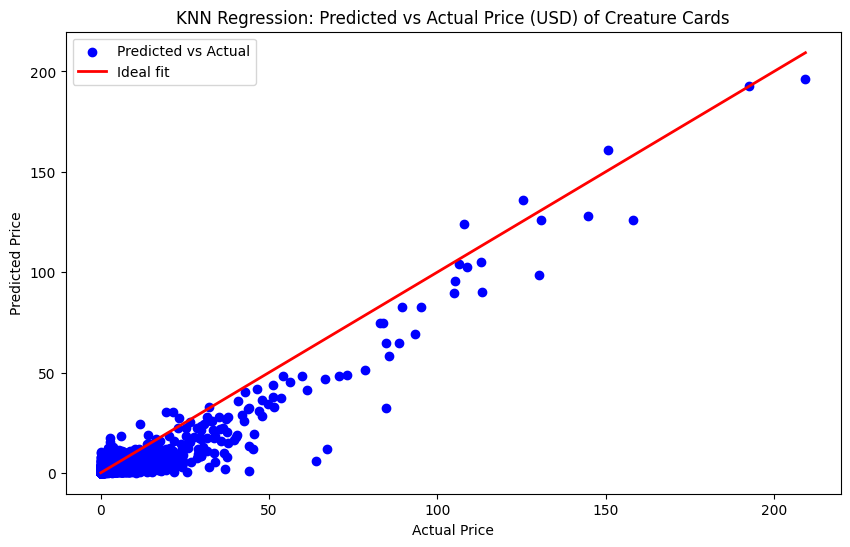

In [38]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_creat, y_pred_creat, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test_creat), max(y_test_creat)], [min(y_test_creat), max(y_test_creat)], color='red', linewidth=2, label='Ideal fit')
plt.title('KNN Regression: Predicted vs Actual Price (USD) of Creature Cards')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.show()

In [39]:
scaler = StandardScaler()
X_train_nc = scaler.fit_transform(X_train_nc)
X_test_nc = scaler.transform(X_test_nc)

knn_regressor = KNeighborsRegressor(n_neighbors=5)
knn_regressor.fit(X_train_nc, y_train_nc)

y_pred_nc = knn_regressor.predict(X_test_nc)

nc_mae = mean_absolute_error(y_test_nc, y_pred_nc)
nc_mse = mean_squared_error(y_test_nc, y_pred_nc)
nc_r2 = r2_score(y_test_nc, y_pred_nc)

print(f'Mean Absolute Error: {nc_mae}')
print(f'Mean Squared Error: {nc_mse}')
print(f'R-squared: {nc_r2}')

Mean Absolute Error: 8.577227734849266
Mean Squared Error: 2593.099728021225
R-squared: -0.040475651398165446


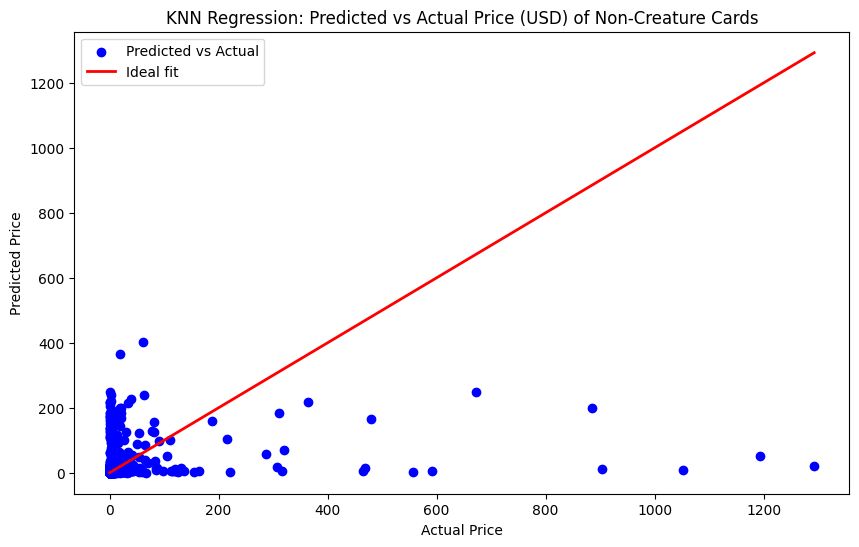

In [40]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_nc, y_pred_nc, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test_nc), max(y_test_nc)], [min(y_test_nc), max(y_test_nc)], color='red', linewidth=2, label='Ideal fit')
plt.title('KNN Regression: Predicted vs Actual Price (USD) of Non-Creature Cards')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.show()

In [41]:
scaler = StandardScaler()
X_train_pw = scaler.fit_transform(X_train_pw)
X_test_pw = scaler.transform(X_test_pw)

knn_regressor = KNeighborsRegressor(n_neighbors=3)
knn_regressor.fit(X_train_pw, y_train_pw)

y_pred_pw = knn_regressor.predict(X_test_pw)

pw_mae = mean_absolute_error(y_test_pw, y_pred_pw)
pw_mse = mean_squared_error(y_test_pw, y_pred_pw)
pw_r2 = r2_score(y_test_pw, y_pred_pw)

print(f'Mean Absolute Error: {pw_mae}')
print(f'Mean Squared Error: {pw_mse}')
print(f'R-squared: {pw_r2}')

Mean Absolute Error: 5.95643803150553
Mean Squared Error: 183.52955654415499
R-squared: 0.14196010631470146


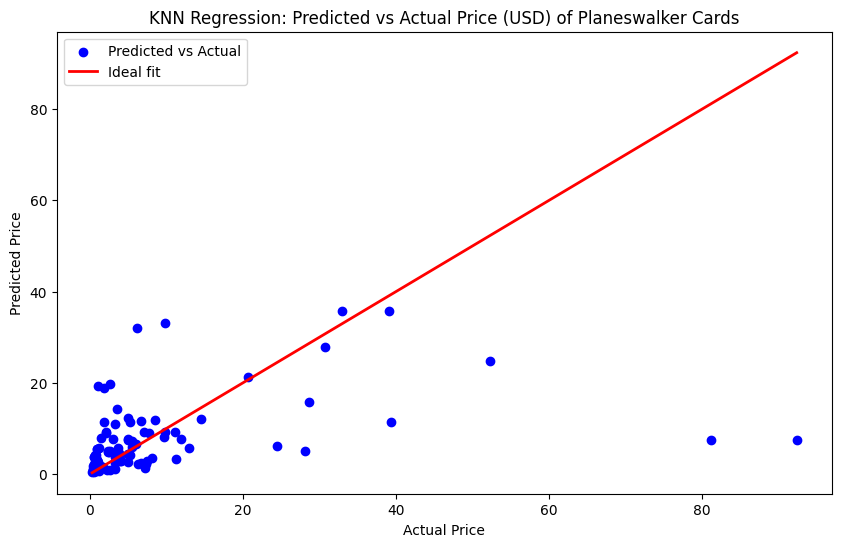

In [42]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_pw, y_pred_pw, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test_pw), max(y_test_pw)], [min(y_test_pw), max(y_test_pw)], color='red', linewidth=2, label='Ideal fit')
plt.title('KNN Regression: Predicted vs Actual Price (USD) of Planeswalker Cards')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.show()